In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [4]:
df = pd.read_csv('../data/raw/cms/CostReport_2018_Final.csv',
                 low_memory=False)

print(f'Shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')
for col in df.columns[:30]:
    print(f'  {col}: {df[col].dtype}')

df.head(3)

Shape: (6160, 117)

Columns (117):
  rpt_rec_num: int64
  Provider CCN: int64
  Hospital Name: object
  Street Address: object
  City: object
  State Code: object
  Zip Code: object
  County: object
  Medicare CBSA Number: float64
  Rural Versus Urban: object
  CCN Facility Type: object
  Provider Type: int64
  Type of Control: int64
  Fiscal Year Begin Date: object
  Fiscal Year End Date: object
  FTE - Employees on Payroll: float64
  Number of Interns and Residents (FTE): float64
  Total Days Title V: float64
  Total Days Title XVIII: float64
  Total Days Title XIX: float64
  Total Days (V + XVIII + XIX + Unknown): float64
  Number of Beds: float64
  Total Bed Days Available: float64
  Total Discharges Title V: float64
  Total Discharges Title XVIII: float64
  Total Discharges Title XIX: float64
  Total Discharges (V + XVIII + XIX + Unknown): float64
  Number of Beds + Total for all Subproviders: float64
  Hospital Total Days Title V For Adults & Peds: float64
  Hospital Total Days T

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
0,639197,51994,FERN LODGE INC,18457 MADISON AVE,CASTRO VALLEY,CA,94546-1637,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,644158,341318,CHOWAN HOSPITAL INC.,211 VIRGINIA AVENUE,EDENTON,NC,27932,CHOWAN,99934.0,R,...,5905119.0,1211964.0,7117083.0,NaN,7117083.0,0.342405,7305948.0,17818589.0,38906.0,180387.0
2,644255,102012,SPECIALTY HOSPITAL OF JACKSONVILLE,4901 RICHARD STREET,JACKSONVILLE,FL,32207,DUVAL,27260.0,U,...,-1970065.0,35748.0,-1934317.0,-522.0,-1933795.0,NaN,NaN,NaN,NaN,NaN


In [6]:
financial_cols = [
    'Total Patient Revenue',
    'Total Costs',
    'Net Income',
    'Less Total Operating Expense',
    'Number of Beds',
    'Cash on Hand and in Banks',
    'Inpatient Total Charges',
    'Medicaid Charges'
]

missing = df[financial_cols].isnull().mean().sort_values(ascending=False)
print('Missing rate per financial column:')
print(missing.round(3))

Missing rate per financial column:
Medicaid Charges                0.257
Cash on Hand and in Banks       0.080
Total Patient Revenue           0.041
Net Income                      0.015
Number of Beds                  0.013
Inpatient Total Charges         0.013
Total Costs                     0.013
Less Total Operating Expense    0.013
dtype: float64


In [9]:
rucc = pd.read_csv('../data/raw/usda/rucc_2013.csv', encoding='latin-1')

rucc['county_normalized'] = (
    rucc['County_Name']
    .str.upper()
    .str.replace(' COUNTY', '', regex=False)
    .str.strip()
)

df['county_normalized'] = df['County'].str.upper().str.strip()

df_joined = df.merge(
    rucc[['State', 'county_normalized', 'RUCC_2013']],
    left_on=['State Code', 'county_normalized'],
    right_on=['State', 'county_normalized'],
    how='left'
)

print(f'Rows after join: {len(df_joined)}')
print(f'RUCC_2013 null after join: {df_joined["RUCC_2013"].isnull().sum()}')
print(f'\nRUCC code distribution:')
print(df_joined['RUCC_2013'].value_counts().sort_index())

df_rural = df_joined[df_joined['RUCC_2013'] >= 4]
print(f'\nRural hospitals (RUCC >= 4): {len(df_rural)}')

Rows after join: 6160
RUCC_2013 null after join: 741

RUCC code distribution:
RUCC_2013
1.0    1930
2.0    1013
3.0     614
4.0     331
5.0     144
6.0     605
7.0     443
8.0     114
9.0     225
Name: count, dtype: int64

Rural hospitals (RUCC >= 4): 1862


Total closures in dataset: 110

Columns: ['hospital_name', 'city', 'state', 'closure_year']

Closures by year:
closure_year
2005     5
2006     4
2007     5
2008     6
2009     3
2010     2
2011     2
2012     4
2013     5
2014     8
2015    11
2016     5
2017     7
2018     9
2019    10
2020     8
2022     3
2023     5
2024     4
2025     4
Name: count, dtype: int64


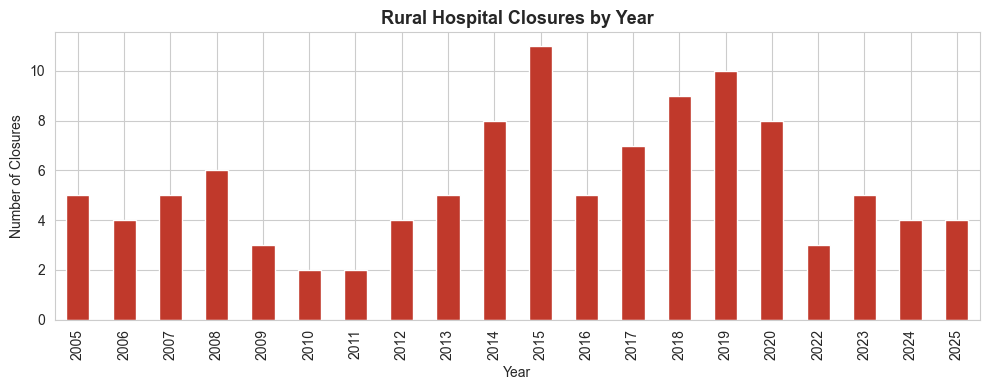

In [10]:
closures = pd.read_csv('../data/raw/sheps/rural_closures.csv')

print(f'Total closures in dataset: {len(closures)}')
print(f'\nColumns: {closures.columns.tolist()}')

closure_by_year = closures['closure_year'].value_counts().sort_index()
print('\nClosures by year:')
print(closure_by_year)

fig, ax = plt.subplots(figsize=(10, 4))
closure_by_year.plot(kind='bar', ax=ax, color='#C0392B')
ax.set_title('Rural Hospital Closures by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Closures')
plt.tight_layout()
plt.savefig('../docs/closures_by_year.png', dpi=150)
plt.show()

In [11]:
# ⚠ DEVIATION: Reference guide joins on provider_ccn.
# Sheps file has no CCN — matching on hospital_name + state instead.

closures_2018 = closures[closures['closure_year'] == 2018].copy()
closures_2018['name_normalized'] = closures_2018['hospital_name'].str.upper().str.strip()

df['name_normalized'] = df['Hospital Name'].str.upper().str.strip()

closed_pairs = set(
    zip(
        closures_2018['name_normalized'],
        closures_2018['state'].str.upper().str.strip()
    )
)

df['is_closed'] = df.apply(
    lambda row: 1 if (row['name_normalized'],
                      str(row['State Code']).upper().strip()) in closed_pairs
                  else 0,
    axis=1
)

print(f'Hospitals flagged as closed in 2018: {df["is_closed"].sum()}')

df['operating_margin'] = (
    (df['Total Patient Revenue'] - df['Less Total Operating Expense']) /
    df['Total Patient Revenue']
).replace([float('inf'), float('-inf')], float('nan'))

print('\nMedian operating margin:')
print(df.groupby('is_closed')['operating_margin'].median().round(4))

Hospitals flagged as closed in 2018: 5

Median operating margin:
is_closed
0    0.6446
1    0.8195
Name: operating_margin, dtype: float64
